In [1]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np
from skimage.morphology import skeletonize
from sklearn.cluster import DBSCAN

function to select all the file we want to process. can be a single file or a folder

In [2]:
def select_images(path): # can pass a single image or a folder
    supported_formats = (".png", ".jpg", ".jpeg")
    images = []

    # single image
    if os.path.isfile(path):
        if path.lower().endswith(supported_formats):
            images.append(path)
        else:
            print(f"File {path} has not a supported image format")

    # folder
    elif os.path.isdir(path):       
        for filename in os.listdir(path):
            if filename.lower().endswith(supported_formats):
                img_path = os.path.join(path, filename)
                images.append(img_path)

    return images # list of images to process

PREPROCESSING


binarization (adaptive thresholding to overcome the problem of different light in some zones (ex. scanned img); inverse thresholding because later process requires white walls, ), noise removal (gaussian blur the most used with a 5x5 kernel)

CHECK IF TO DO BLURRING EVEN IF THE IMG IN INPUT IS ALREADY BLURRED

In [3]:
def preprocess(img):
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    noise_reduced_img = cv2.GaussianBlur(gray_img, (5, 5), 0) # 0 to let it compute sigma
    #inverse adaptive thresholding
    binary_img = cv2.adaptiveThreshold(noise_reduced_img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, blockSize = 25, C = 10)

    # subplots because using plot it gets overwritten
    # figsize proportional to img resolution, to avoid distortion
    _, axes = plt.subplots(1, 4, figsize=(img.shape[1]*4/100, img.shape[0]/100))
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)) # original img
    axes[0].set_title("Original")
    axes[1].imshow(gray_img, cmap='gray') # grayscale img
    axes[1].set_title("Grayscale")
    axes[2].imshow(noise_reduced_img, cmap='gray') # blurred img
    axes[2].set_title("Blurred")
    axes[3].imshow(binary_img, cmap='gray') # binary img
    axes[3].set_title("Inverse Binary")

    for ax in axes:
        ax.axis('off')

    plt.tight_layout() # adjust padding
    plt.show()

    return binary_img



MIDDLE PROCESSING -> WALL DETECTION

distance transorm --> thick structures = white in the centre, more black going on borders, small structures will be all dark

threshold --> keep only pixels with distance > 3 

morphologyEx, MORPH_CLOSE --> erosion (take min of neighbours) of the dilatated (take max of the neighbours) img 

In [4]:
def isolate_walls(img):
    
    # each pixel is substituted by its distance to the nearest black pixel
    dist_img = cv2.distanceTransform(img, cv2.DIST_L2, 5)
    
    # keep only thick lines (= walls)
    _, walls_img = cv2.threshold(dist_img, 3.0, 255, cv2.THRESH_BINARY)

    # close small gaps in walls
    kernel = np.ones((5, 5), np.uint8)
    walls_img = cv2.morphologyEx(walls_img, cv2.MORPH_CLOSE, kernel)

    _, axes = plt.subplots(1, 3, figsize=(img.shape[1]*4/100, img.shape[0]*4/100))
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title("Binary")
    axes[1].imshow(dist_img, cmap='gray')
    axes[1].set_title("Distance map")
    axes[2].imshow(walls_img, cmap='gray')
    axes[2].set_title("Walls only")
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()

    return walls_img

In [5]:
def detect_walls(img):

    # thin img -> 1px lines
    skeletonized_img = skeletonize(img // 255).astype(np.uint8) * 255

    # to have hough transform parameters proportional to img size
    h, w = skeletonized_img.shape

    # detect img (straight segments)
    detected_segments = cv2.HoughLinesP(
        skeletonized_img,
        rho = 1,                                    # search every pixel
        theta = np.pi / 180,                        # foreach pixel search every degree
        threshold = int(min(h, w) * 0.01),          
        minLineLength = int(min(h, w) * 0.01),
        maxLineGap = int(min(h, w) * 0.005)
    )

    detected_segments = [seg[0].tolist() for seg in detected_segments] # unwrap the output so to have a list of segments

    height, width = img.shape
    drawn_walls_img = np.zeros((height, width, 3), dtype=np.uint8)
    for segment in detected_segments:
        x1 = segment[0]
        y1 = segment[1]
        x2 = segment[2]
        y2 = segment[3]
        cv2.line(drawn_walls_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    _, axes = plt.subplots(1, 3, figsize = (img.shape[1]*4/100, img.shape[0]*4/100))
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title("Walls")
    axes[1].imshow(skeletonized_img, cmap='gray')
    axes[1].set_title("Skeleton")
    axes[2].imshow(drawn_walls_img)
    axes[2].set_title(f"Detected segments ({len(detected_segments) if detected_segments is not None else 0})")
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()

    return detected_segments

SEMANTIC STEP: RECONSTRUCT LINES GOT FROM HOUGH

-> correct angles to be 45,90...
-> close holes

In [6]:
def snap_angle(angle_degree, tolerance=10):
    target_angles = [0, 45, 90, 135, 180]
    closest_angle = min(target_angles, key=lambda t: abs(angle_degree - t))
    
    if abs(angle_degree - closest_angle) <= tolerance:
        return closest_angle 
    return angle_degree

def snap_segments_angle(segments):
    snapped = []
    for segment in segments:
        x1 = segment[0]
        y1 = segment[1]
        x2 = segment[2]
        y2 = segment[3]
        angle = np.degrees(np.atan2(y2 - y1, x2 - x1)) # get angle
        corrected_angle = snap_angle(angle)

        if corrected_angle != angle:
            # recompute endpoint based on snapped angle
            length = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
            angle_radians = np.radians(corrected_angle)
            x2 = int(x1 + length * np.cos(angle_radians))
            y2 = int(y1 + length * np.sin(angle_radians))

        snapped.append([x1, y1, x2, y2])
        
    return snapped

In [7]:
def merge_segments(segments, distance_threshold=10):
    
    # represent each segment by its midpoint and angle
    features = []
    for segment in segments:
        x1 = segment[0]
        y1 = segment[1]
        x2 = segment[2]
        y2 = segment[3]
        x_mean = (x1 + x2) / 2
        y_mean = (y1 + y2) / 2
        angle = np.degrees(np.atan2(y2 - y1, x2 - x1)) # get angle
        features.append([x_mean, y_mean, angle * 10]) # "normalize" angle to give same weight in dbscan

    features = np.array(features)

    # cluster segments (assign the same cluster label) that are close in position and angle 
    clusters = DBSCAN(eps=distance_threshold, min_samples=1).fit(features) # min samples 1 to allow isolated segments to be their own cluster

    # merge clusters (pieces of the same segment)
    merged = []
    for label in set(clusters.labels_):
        cluster_indices = np.where(clusters.labels_ == label)[0] # get indexes (in the original list) of segments in this cluster label
        cluster_segments = [segments[i] for i in cluster_indices] # extract segments by their indexes

        # merge cluster into one segment by taking the extremes
        all_x = [s[0] for s in cluster_segments] + [s[2] for s in cluster_segments] # get all the x coord of segments endpoints in the cluster
        all_y = [s[1] for s in cluster_segments] + [s[3] for s in cluster_segments] # get all the y coord of segments endpoints in the cluster
        merged.append([min(all_x), min(all_y), max(all_x), max(all_y)])

    return merged

In [11]:
def snap_corners(segments, snap_distance=15):
    
    # reason on endpoints distance
    endpoints = []
    for segment in segments:
        endpoints.append((segment[0], segment[1]))  # start point
        endpoints.append((segment[2], segment[3]))  # end point

    # for each endpoint, find nearby endpoints and average them
    snapped_points = {}
    for i, (x1, y1) in enumerate(endpoints):
        if i in snapped_points:
            continue
        cluster = [(x1, y1)]
        for j, (x2, y2) in enumerate(endpoints):
            if i != j and np.hypot(x2 - x1, y2 - y1) < snap_distance:
                cluster.append((x2, y2))
    
    # compute average position of the cluster
    avg_x = int(sum(p[0] for p in cluster) / len(cluster))
    avg_y = int(sum(p[1] for p in cluster) / len(cluster))
    
    # store the averaged position for ALL points in the cluster
    snapped_points[i] = (avg_x, avg_y)
    for j, (x2, y2) in enumerate(endpoints):
        if i != j and np.hypot(x2 - x1, y2 - y1) < snap_distance:
            snapped_points[j] = (avg_x, avg_y)
            
    # rebuild segments with snapped endpoints
    result = []
    for idx, segment in enumerate(segments):
        p1 = snapped_points.get(idx * 2, (segment[0], segment[1]))
        p2 = snapped_points.get(idx * 2 + 1, (segment[2], segment[3]))
        result.append([p1[0], p1[1], p2[0], p2[1]])

    return result

In [9]:
def regularize(segments, img_shape):
    h, w = img_shape

    # 1. snap angles
    snapped = snap_segments_angle(segments)

    # 2. merge collinear/duplicate segments
    merged = merge_segments(snapped, distance_threshold=int(min(h,w) * 0.01))

    # 3. snap corners
    final = snap_corners(merged, snap_distance=int(min(h,w) * 0.007))

    return final


def draw_regularized(segments, img_shape):
    h, w = img_shape
    canvas = np.zeros((h, w, 3), dtype=np.uint8)
    for x1, y1, x2, y2 in segments:
        cv2.line(canvas, (x1, y1), (x2, y2), (0, 255, 0), 2)

    plt.imshow(canvas, cmap='gray')
    return canvas


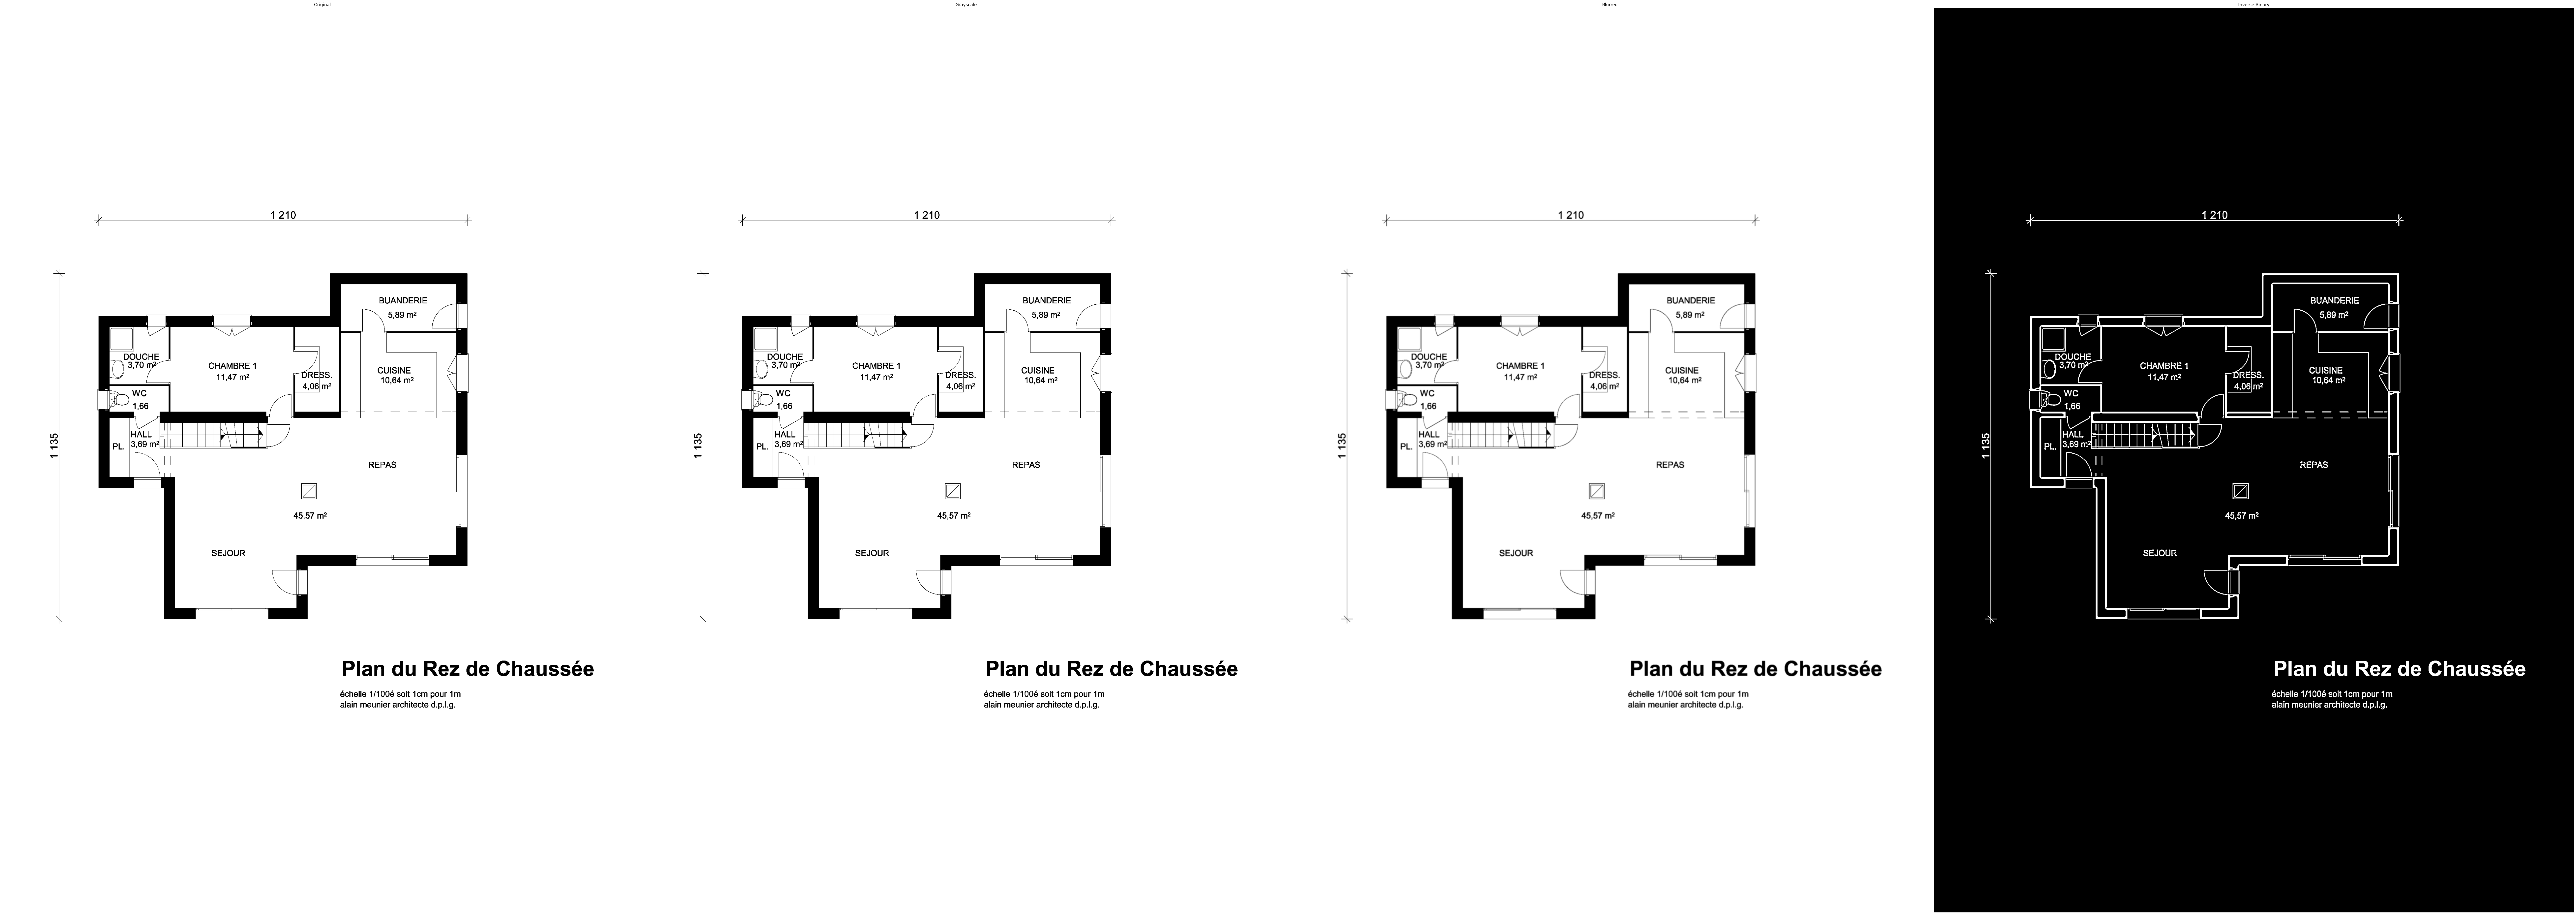

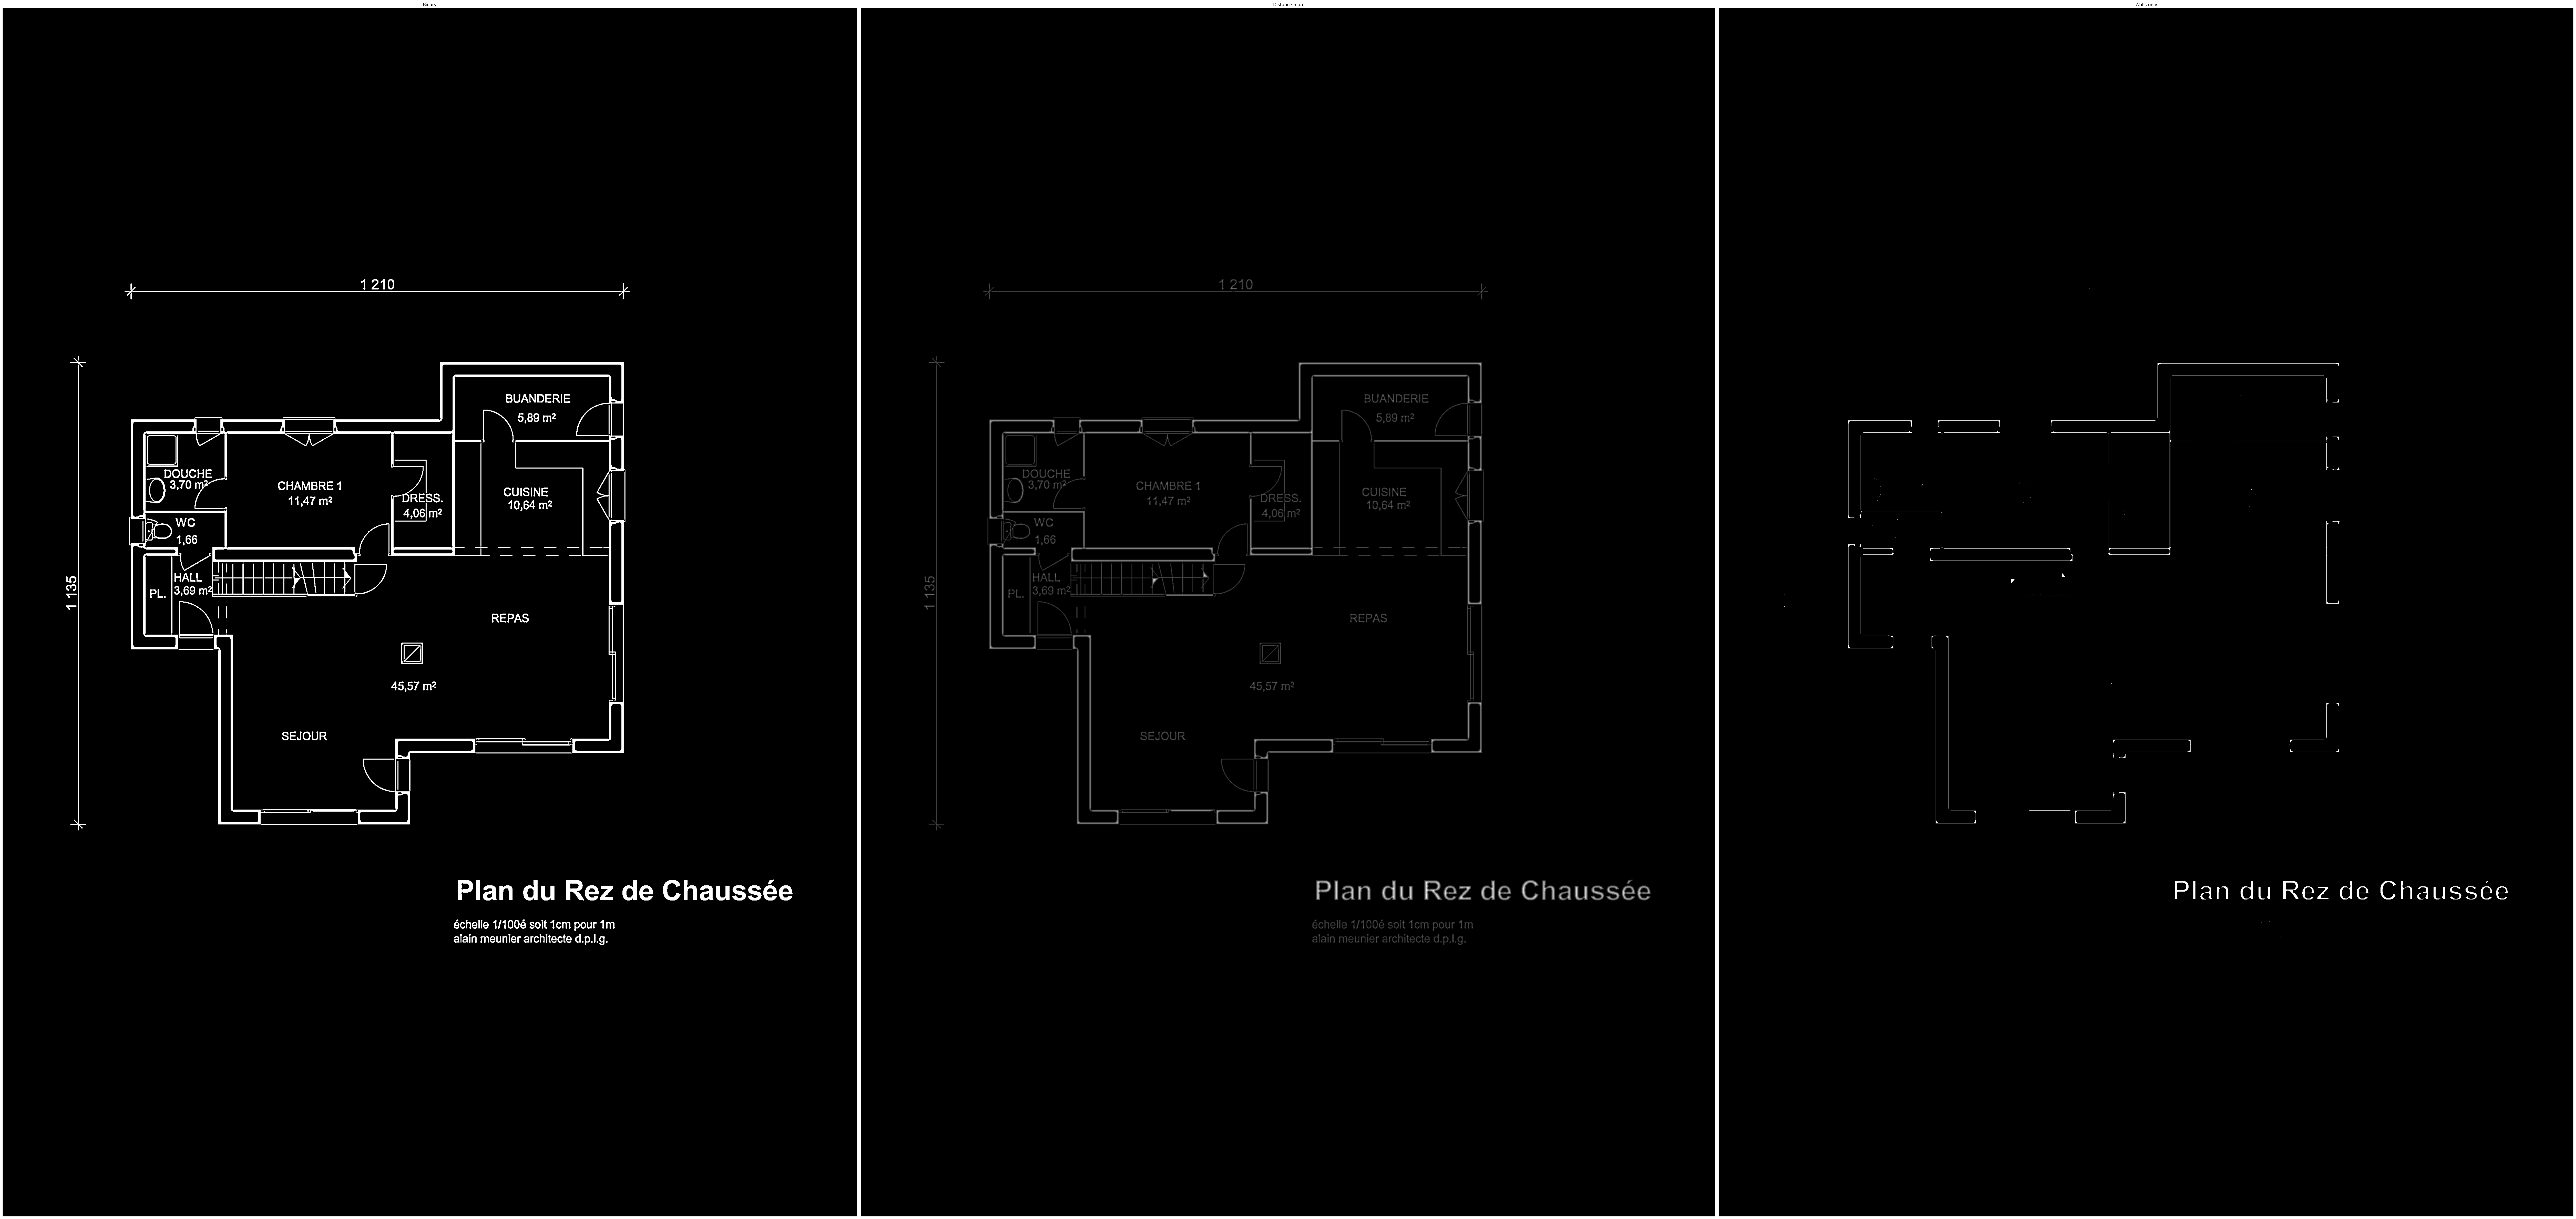

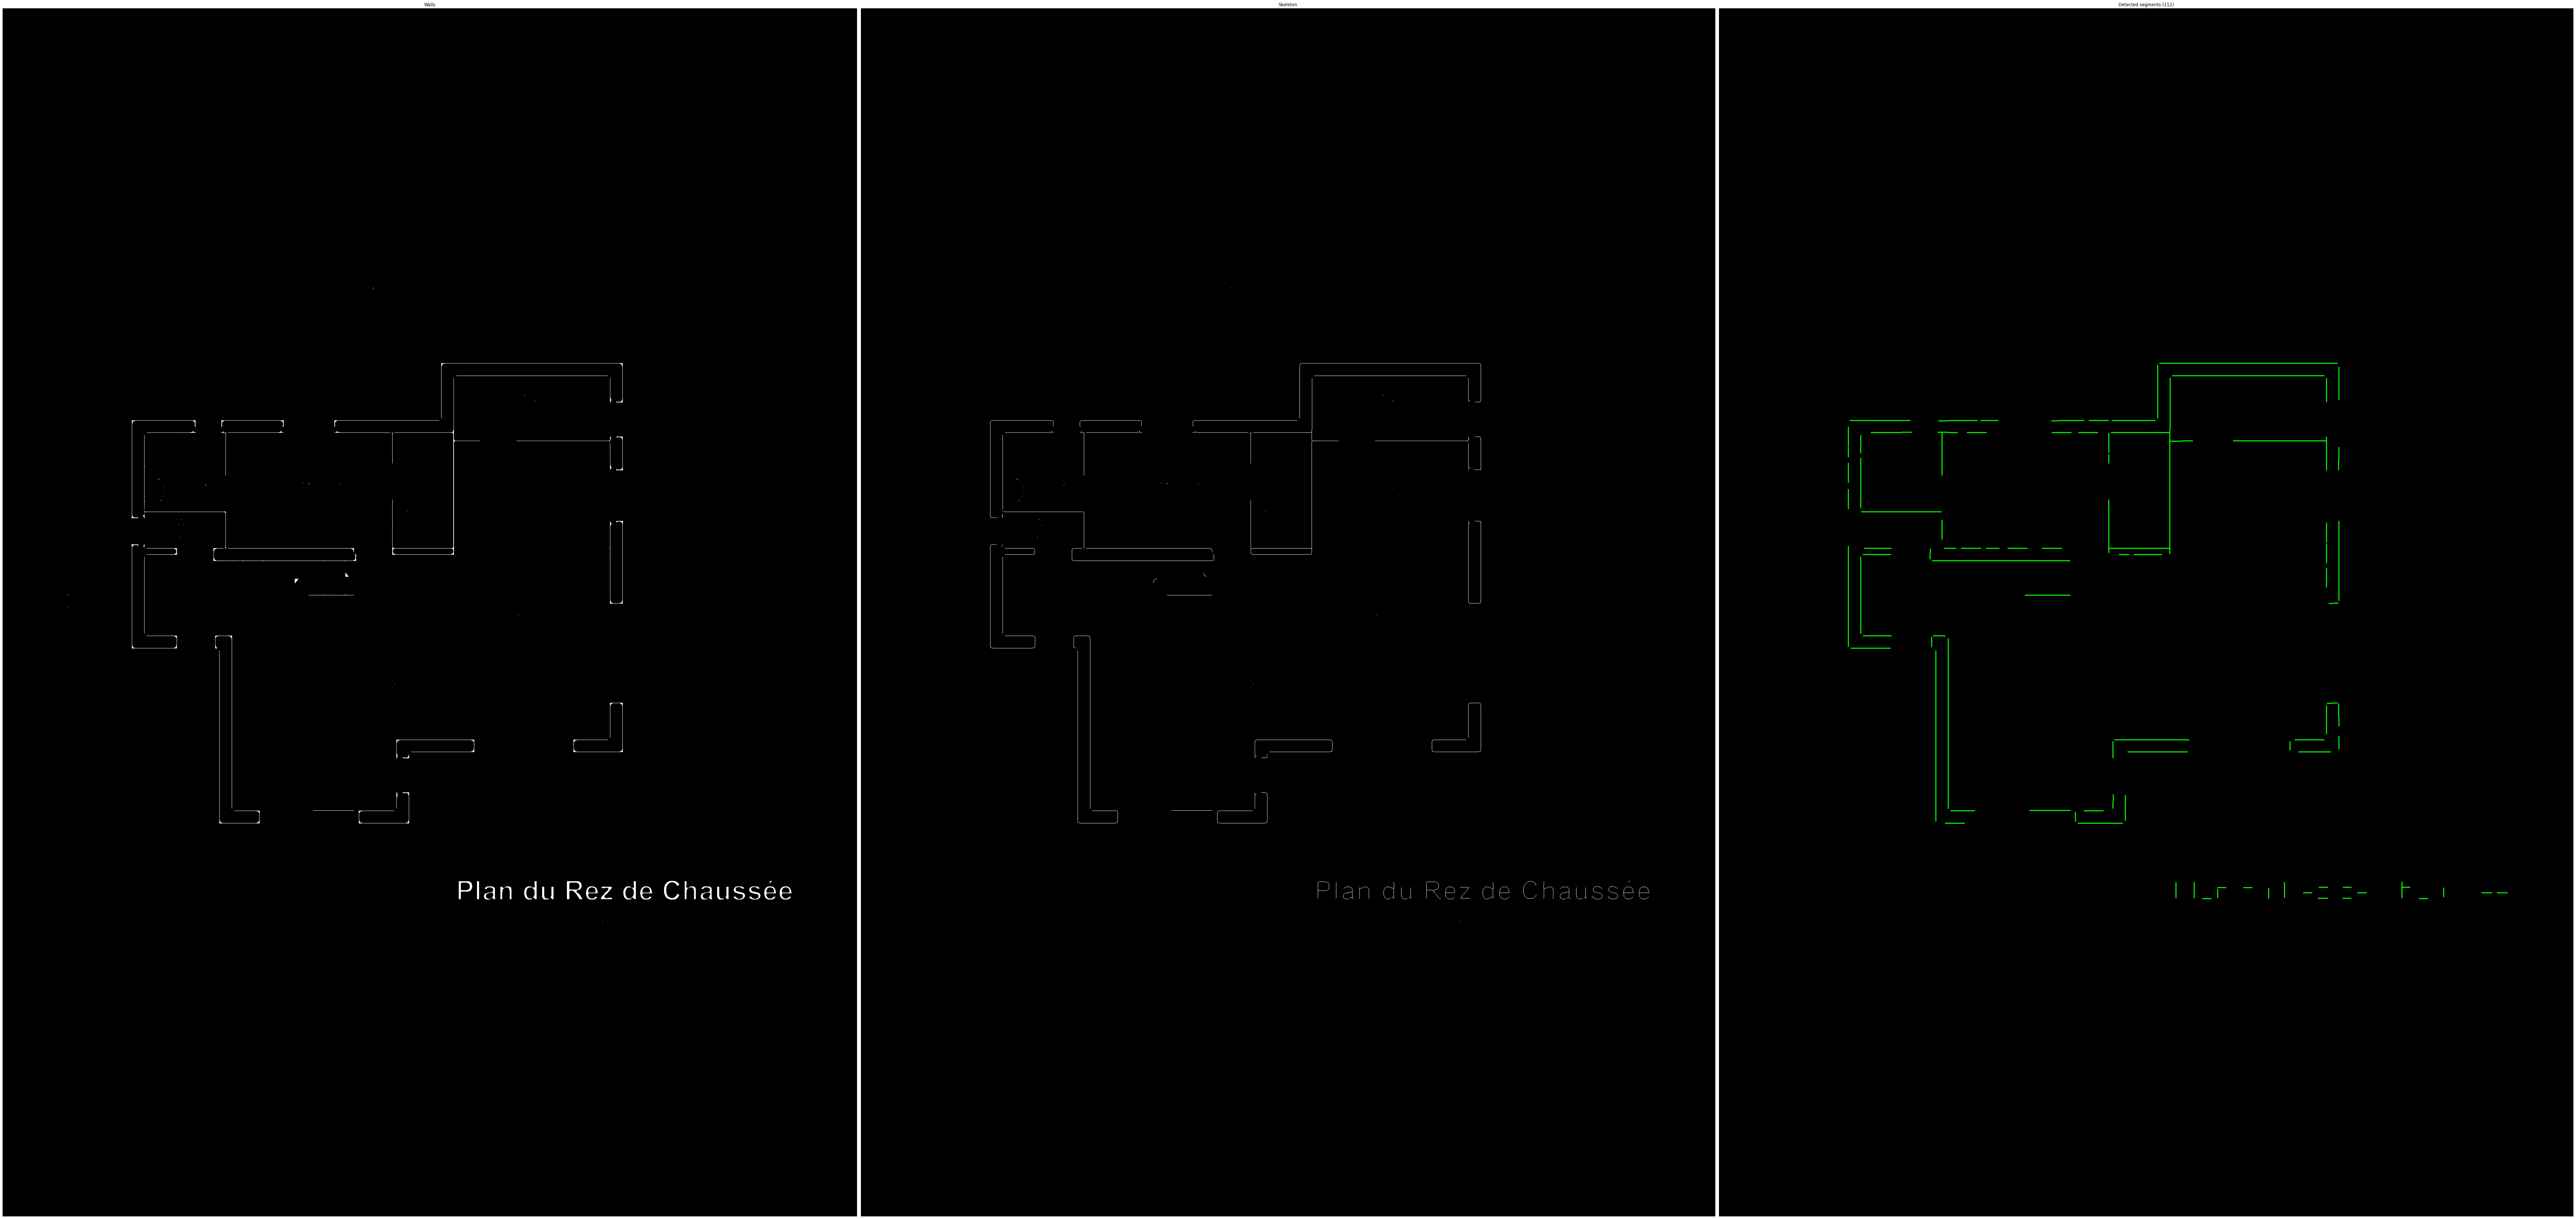

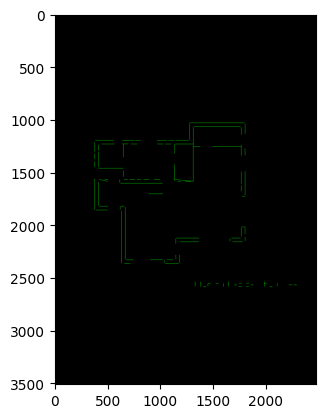

In [12]:
img = cv2.imread (input("Enter the path to the images to preprocess: "))
imgg = preprocess(img)
imggg = isolate_walls(imgg)
imgggg = detect_walls(imggg)
regularized = regularize(imgggg, img.shape[:2])
canvas = draw_regularized(regularized, img.shape[:2])